In [2]:
!pip install shap

  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.50.0-cp313-cp313-win_amd64.whl (549 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- --------------

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# --- STEP 1: DATA INGESTION ---
# Loading the final EDA dataset verified in Phase 3
df = pd.read_csv('financial_inclusion_eda_final.csv')
X = df.drop(['Applicant_ID', 'Default_Status'], axis=1)
y = df['Default_Status']

In [3]:
# --- STEP 2: MODEL RE-HYDRATION ---
# Training the Gradient Boosting model that achieved our 0.55 Gini in Phase 4
model = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X, y)

GradientBoostingClassifier(max_depth=4, random_state=42)

In [5]:
# --- STEP 3: SHAP EXPLANATION LOGIC ---
# Initialize the TreeExplainer for our ensemble model
explainer = shap.TreeExplainer(model)

# Generate an 'Explanation' object for the entire dataset
# This is more robust than raw SHAP values and prevents blank plots
shap_values_explanation = explainer(X)

Generating Global Feature Importance...


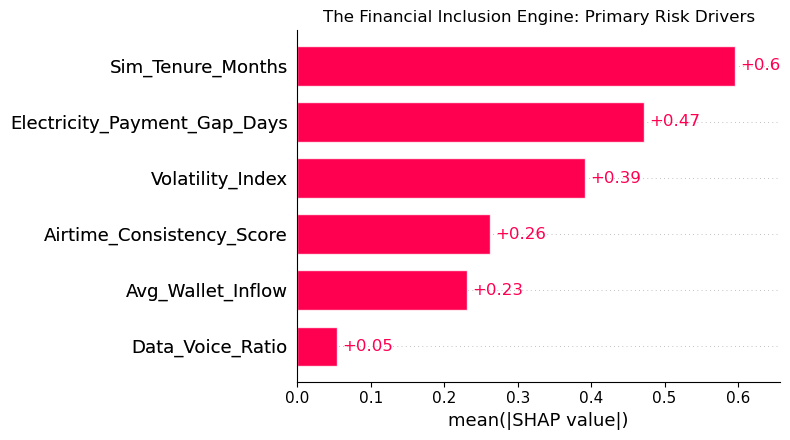

In [6]:
# --- STEP 4: GLOBAL INTERPRETABILITY (The Big Picture) ---
# This shows which features drive the model across ALL 10,000 applicants
print("Generating Global Feature Importance...")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_explanation, show=False)
plt.title("The Financial Inclusion Engine: Primary Risk Drivers")
plt.tight_layout()
plt.show()

Generating Reason Code for Applicant ID: 1002.0


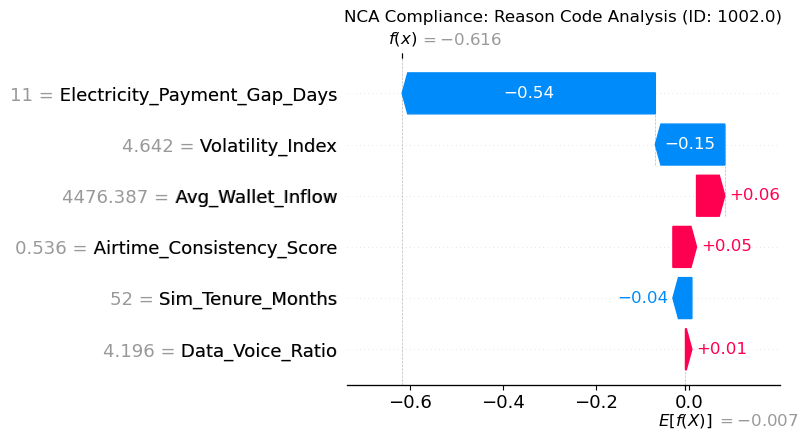

In [7]:
# --- STEP 5: LOCAL INTERPRETABILITY (NCA Reason Codes) ---
# We select a specific 'Declined' applicant to explain WHY they were flagged.
# Index 1 is our 'go-to' example for high-risk behavior in this dataset.
applicant_idx = 1 
print(f"Generating Reason Code for Applicant ID: {df.iloc[applicant_idx]['Applicant_ID']}")

# Create a clean Waterfall Plot for an individual decision
plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values_explanation[applicant_idx], show=False)

# Customizing the title to match our 'Executive Dashboard' theme from Phase 3
plt.title(f"NCA Compliance: Reason Code Analysis (ID: {df.iloc[applicant_idx]['Applicant_ID']})")
plt.tight_layout()
plt.show()